# Weather-robustness analysis (§4.2) — Swin-T vs FlashInternImage

The in-domain checkpoints (§4.1), unchanged, are run on an **adverse-weather** set
(dry / wet / half-wet). Overall mIoU collapses from ~40 (in-domain) to single digits. This
notebook interrogates that collapse:

1. Is it **real or a metric artifact** (many classes absent from the weather GT)?
2. Is it **worse when wetter** (dry vs half vs wet)?
3. **Why** does it happen — where does the prediction mass go, what is confused?
4. Does anything **recover** it — coarse grouping, boundary tolerance, Swin∨Flash ensemble?
5. **Failure mode** — false positives vs missed detections, per class.
6. Same-scene-ish comparison across conditions + qualitative panels.

Built on the §4.1 `qualitative_reorganized.ipynb` (same helpers/palette), re-framed on the weather
**condition** axis. Inputs: `data/output/weather/<model>/<cond>/pred_masks/`, GT
`data/final_dataset/labels_720/`, originals `data/final_dataset/images/`, splits `.../splits/{dry,wet,half}.txt`.

In [1]:
import collections, itertools
from pathlib import Path
from functools import lru_cache
import numpy as np, cv2, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches, seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# ---- config ----
BASE_APP_DIR = next((p for p in [Path('/app'), Path.cwd(), *Path.cwd().parents]
                     if (p / 'data' / 'final_dataset').exists()), Path('/app'))
MODELS = ['swin', 'flash']            # only these two have full weather runs
CONDITIONS = ['dry', 'wet', 'half']
DATA = BASE_APP_DIR / 'data' / 'final_dataset'
PATHS = {'images': DATA / 'images', 'gt': DATA / 'labels_720', 'splits': DATA / 'splits'}
def pred_dir(m, c): return BASE_APP_DIR / 'data' / 'output' / 'weather' / m / c / 'pred_masks'

CLASS_NAMES = ['bg', 'cracks', 'cracks_alligator', 'cracks_severe', 'edge_cracks',
               'fretting', 'pothole', 'manhole', 'pole_shadow']
PALETTE = [[0,0,0],[250,50,83],[36,179,83],[102,204,255],[255,165,0],[128,128,128],[255,255,0],[0,255,255],[255,0,255]]
N = len(CLASS_NAMES)
CMAP = ListedColormap(np.array(PALETTE) / 255); NORM = BoundaryNorm(np.arange(-0.5, N + 0.5), CMAP.N)
GROUPS = {'bg': ['bg'], 'crack': ['cracks','cracks_alligator','cracks_severe','edge_cracks'],
          'fretting': ['fretting'], 'pothole': ['pothole'], 'manhole': ['manhole'], 'pole_shadow': ['pole_shadow']}
INDOMAIN_MIOU = {'swin': 40.00, 'flash': 41.40}    # §4.1 test mIoU (docs/RESULTS.md)
print('BASE_APP_DIR =', BASE_APP_DIR)

BASE_APP_DIR = /app


In [3]:
# ---- helpers ----
def image_ids(cond):
    f = PATHS['splits'] / f'{cond}.txt'
    return [l.strip() for l in f.read_text().splitlines() if l.strip()] if f.exists() else []

@lru_cache(maxsize=None)
def _imread_gray(p): return cv2.imread(p, cv2.IMREAD_GRAYSCALE)

@lru_cache(maxsize=None)
def load_aligned(model, cond, img_id):
    gt_p, pr_p = PATHS['gt'] / f'{img_id}.png', pred_dir(model, cond) / f'{img_id}.png'
    if not gt_p.exists() or not pr_p.exists(): return None, None
    gt, pr = _imread_gray(str(gt_p)), _imread_gray(str(pr_p))
    if gt is None or pr is None: return None, None
    if pr.shape != gt.shape:
        pr = cv2.resize(pr, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)
    return gt, pr

def _load_rgb(img_id):
    p = PATHS['images'] / f'{img_id}.jpg'
    return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) if p.exists() else None

def overlay_gt(img_id, alpha=0.5):
    rgb = _load_rgb(img_id); gt = cv2.imread(str(PATHS['gt'] / f'{img_id}.png'), cv2.IMREAD_GRAYSCALE)
    if rgb is None or gt is None: return rgb
    if gt.shape != rgb.shape[:2]:
        gt = cv2.resize(gt, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    col = (CMAP(NORM(gt))[..., :3] * 255).astype(np.uint8)
    out, mk = rgb.copy(), gt > 0; out[mk] = (alpha * col[mk] + (1 - alpha) * rgb[mk]).astype(np.uint8)
    return out

@lru_cache(maxsize=None)
def confusion(model, cond):
    cm = np.zeros((N, N), np.int64)
    for i in image_ids(cond):
        gt, pr = load_aligned(model, cond, i)
        if gt is not None:
            cm += np.bincount(N * gt.ravel() + pr.ravel(), minlength=N * N).reshape(N, N)
    return cm

def per_class_iou(cm):
    inter = np.diag(cm).astype(float); union = cm.sum(1) + cm.sum(0) - inter
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(union > 0, 100 * inter / union, np.nan)

cms = {(m, c): confusion(m, c) for m in MODELS for c in CONDITIONS}
print('confusion matrices built for', list(cms.keys()))

confusion matrices built for [('swin', 'dry'), ('swin', 'wet'), ('swin', 'half'), ('flash', 'dry'), ('flash', 'wet'), ('flash', 'half')]


## 1. The collapse, and whether it is a metric artifact

`mIoU` averages IoU over all 9 classes; a class absent from the weather GT contributes 0 and drags
the mean down. So we report `mIoU` (all), `mIoU_no_bg` (8 defects) and `mIoU_present` (only classes
that appear in that condition's GT — artifact-free), plus the GT **class support**.

In [4]:
rows = []
for m in MODELS:
    for c in CONDITIONS:
        cm = cms[(m, c)]; pc = per_class_iou(cm); present = cm.sum(1) > 0
        rows.append({'model': m, 'condition': c, 'n_imgs': len(image_ids(c)),
                     'mIoU': np.nanmean(pc), 'mIoU_no_bg': np.nanmean(pc[1:]),
                     'mIoU_present': np.nanmean(pc[present]), 'n_present': int(present.sum())})
summary = pd.DataFrame(rows).round(2)
print(summary.to_string(index=False))
print('\n--- domain-shift drop (in-domain §4.1 -> weather mean mIoU_no_bg) ---')
for m in MODELS:
    wk = summary[summary.model == m]['mIoU_no_bg'].mean()
    print(f'  {m:6s}: in-domain {INDOMAIN_MIOU[m]:.1f} -> weather {wk:.1f} (drop {INDOMAIN_MIOU[m]-wk:.1f} pp)')
sup = {c: (100 * cms[(MODELS[0], c)].sum(1) / cms[(MODELS[0], c)].sum()).round(2) for c in CONDITIONS}
print('\nGT class support (% of GT pixels) per condition:'); display(pd.DataFrame(sup, index=CLASS_NAMES))

model condition  n_imgs  mIoU  mIoU_no_bg  mIoU_present  n_present
 swin       dry      98 14.63        4.40         14.63          9
 swin       wet     180 14.71        4.23         16.55          8
 swin      half      57 14.75        4.84         16.59          8
flash       dry      98 14.61        5.40         14.61          9
flash       wet     180 16.87        6.74         18.98          8
flash      half      57 13.30        3.91         14.96          8

--- domain-shift drop (in-domain §4.1 -> weather mean mIoU_no_bg) ---
  swin  : in-domain 40.0 -> weather 4.5 (drop 35.5 pp)
  flash : in-domain 41.4 -> weather 5.4 (drop 36.0 pp)

GT class support (% of GT pixels) per condition:


,dry,wet,half
bg,97.00,98.44,97.75
cracks,0.42,0.28,0.55
cracks_alligator,0.26,0.05,0.06
cracks_severe,0.32,0.19,0.11
edge_cracks,0.33,0.06,0.23
fretting,1.34,0.82,0.95
pothole,0.19,0.11,0.32
manhole,0.09,0.00,0.00
pole_shadow,0.05,0.04,0.03


## 2. Is the collapse real? — per-class IoU

If `mIoU_present` is also low and the IoU of the **frequent** classes (support above) is low, the
collapse is real, not the absent-class artifact.

In [5]:
pc_df = pd.DataFrame({f'{m}/{c}': per_class_iou(cms[(m, c)]) for m in MODELS for c in CONDITIONS},
                     index=CLASS_NAMES).round(1)
print('Per-class IoU (%) — rows=class, cols=model/condition:'); display(pc_df)

Per-class IoU (%) — rows=class, cols=model/condition:


,swin/dry,swin/wet,swin/half,flash/dry,flash/wet,flash/half
bg,96.5,98.6,94.0,88.4,97.9,88.4
cracks,17.6,21.1,27.8,19.0,24.2,28.3
cracks_alligator,11.7,0.6,9.0,18.2,1.7,0.0
cracks_severe,1.7,3.8,0.0,1.7,12.4,0.0
edge_cracks,0.0,0.0,0.0,0.0,0.0,0.0
fretting,3.9,8.1,1.9,4.0,15.6,3.0
pothole,0.2,0.1,0.0,0.2,0.0,0.0
manhole,0.0,0.0,0.0,0.0,0.0,0.0
pole_shadow,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Is it worse when wetter? — per-condition severity

Per-image defect mIoU distribution by condition. **Caveat:** the three conditions are **different
road sequences** (the sequence hashes are disjoint — no scene appears in more than one condition),
so this comparison is **confounded by scene difficulty**, not a clean weather-only effect. Read the
ordering (expected dry ≥ half ≥ wet) as suggestive, not causal.

Mean per-image defect mIoU by condition:
condition  model
dry        flash    7.76
           swin     8.11
half       flash    6.04
           swin     7.58
wet        flash    9.82
           swin     8.56


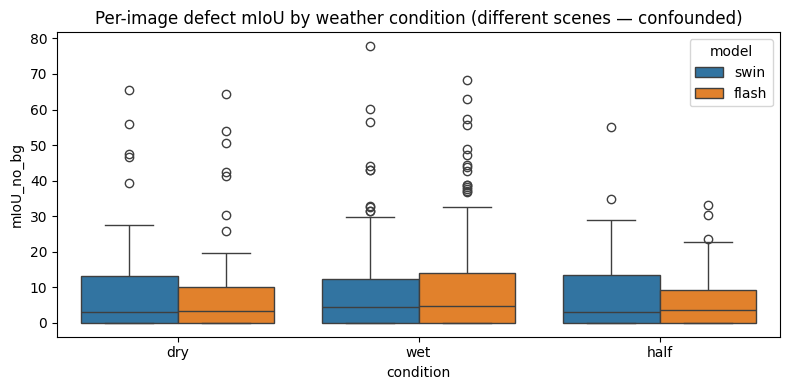

In [6]:
per_img = []
for m in MODELS:
    for c in CONDITIONS:
        for i in image_ids(c):
            gt, pr = load_aligned(m, c, i)
            if gt is None: continue
            cm = np.bincount(N * gt.ravel() + pr.ravel(), minlength=N * N).reshape(N, N)
            per_img.append({'model': m, 'condition': c, 'mIoU_no_bg': np.nanmean(per_class_iou(cm)[1:])})
pi = pd.DataFrame(per_img)
print('Mean per-image defect mIoU by condition:')
print(pi.groupby(['condition', 'model'])['mIoU_no_bg'].mean().round(2).to_string())
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=pi, x='condition', y='mIoU_no_bg', hue='model', order=CONDITIONS, ax=ax)
ax.set_title('Per-image defect mIoU by weather condition (different scenes — confounded)')
plt.tight_layout(); plt.show()

## 4. Why — where does the prediction mass go?

Losing mIoU happens by predicting everything **bg** (misses/FN) or **hallucinating** defects (FP).
We check the predicted-pixel distribution and the fraction of true defect pixels labelled `bg`.

In [7]:
rows = []
for m in MODELS:
    for c in CONDITIONS:
        cm = cms[(m, c)].astype(float); pred_share = cm.sum(0) / cm.sum()
        gt_def = cm[1:, :].sum(); def_to_bg = cm[1:, 0].sum()
        rows.append({'model': m, 'condition': c, 'pred_%bg': round(100 * pred_share[0], 2),
                     'pred_%defect': round(100 * pred_share[1:].sum(), 2),
                     'defect_miss_%(->bg)': round(100 * def_to_bg / max(gt_def, 1), 2)})
print('Prediction mass & defect miss-rate:'); print(pd.DataFrame(rows).to_string(index=False))
print('\n-> high pred_%bg + high defect_miss = collapse toward background (misses defects)')

Prediction mass & defect miss-rate:
model condition  pred_%bg  pred_%defect  defect_miss_%(->bg)
 swin       dry     97.30          2.70                62.14
 swin       wet     98.93          1.07                60.67
 swin      half     93.94          6.06                46.78
flash       dry     88.73         11.27                53.43
flash       wet     97.97          2.03                50.39
flash      half     88.41         11.59                46.29

-> high pred_%bg + high defect_miss = collapse toward background (misses defects)


## 5. What is confused with what — confusion matrices

Row-normalized (recall) per model × condition. The `-> bg` column is the missed-detection story;
off-diagonal among cracks is the subtype-confusion story.

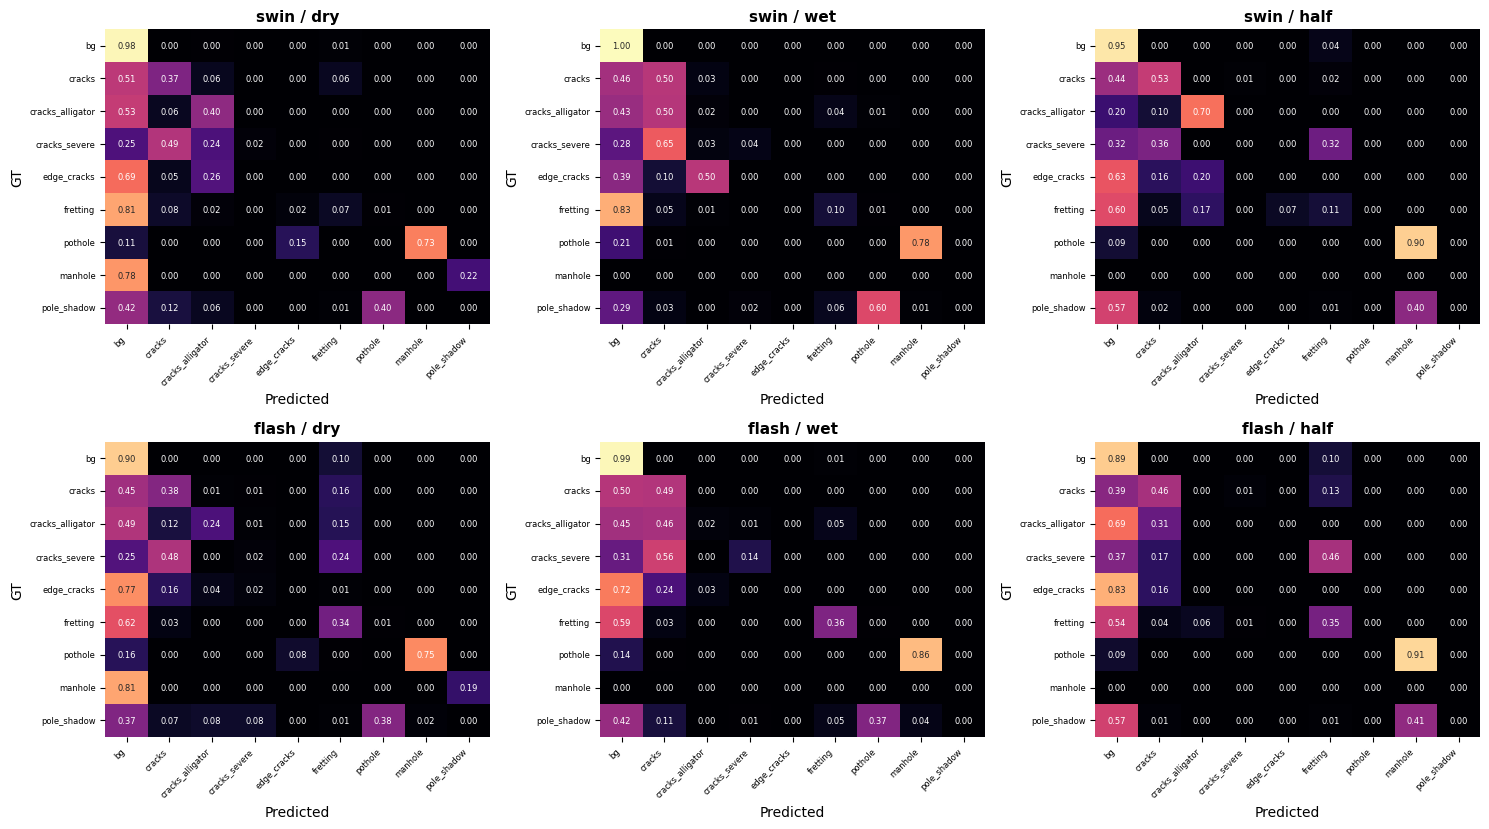

In [8]:
fig, axes = plt.subplots(len(MODELS), len(CONDITIONS), figsize=(5 * len(CONDITIONS), 4.2 * len(MODELS)))
axes = np.atleast_2d(axes)
for i, m in enumerate(MODELS):
    for j, c in enumerate(CONDITIONS):
        cm = cms[(m, c)].astype(float); norm = cm / cm.sum(1, keepdims=True).clip(min=1)
        sns.heatmap(norm, ax=axes[i, j], vmin=0, vmax=1, cmap='magma', cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot=True, fmt='.2f', annot_kws={'size': 6})
        axes[i, j].set_title(f'{m} / {c}', fontweight='bold', fontsize=11)
        axes[i, j].set_xlabel('Predicted'); axes[i, j].set_ylabel('GT')
        axes[i, j].set_xticklabels(axes[i, j].get_xticklabels(), rotation=45, ha='right', fontsize=6)
        axes[i, j].set_yticklabels(axes[i, j].get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout(); plt.show()

## 6. Failure mode — false positives vs missed detections (image level)

Per defect class, pooled over conditions: **miss rate** (GT-positive images where the model predicts
0 px of the class) and **FP rate** (GT-negative images where it predicts the class anyway).

In [9]:
stat = {m: {c: {'gt_pos': 0, 'miss': 0, 'gt_neg': 0, 'fp': 0} for c in range(1, N)} for m in MODELS}
for m in MODELS:
    for cond in CONDITIONS:
        for i in image_ids(cond):
            gt, pr = load_aligned(m, cond, i)
            if gt is None: continue
            gh = np.bincount(gt.ravel(), minlength=N) > 0; ph = np.bincount(pr.ravel(), minlength=N) > 0
            for c in range(1, N):
                if gh[c]: stat[m][c]['gt_pos'] += 1; stat[m][c]['miss'] += int(not ph[c])
                else:     stat[m][c]['gt_neg'] += 1; stat[m][c]['fp'] += int(ph[c])
def _r(d, a, b): return round(100 * d[a] / d[b], 1) if d[b] else np.nan
det = [{'model': m, 'class': CLASS_NAMES[c], 'gt_imgs': stat[m][c]['gt_pos'],
        'miss_rate_%': _r(stat[m][c], 'miss', 'gt_pos'), 'clean_imgs': stat[m][c]['gt_neg'],
        'FP_rate_%': _r(stat[m][c], 'fp', 'gt_neg')} for m in MODELS for c in range(1, N)]
print('Missed-detection & false-positive rates (image level, pooled over conditions):')
display(pd.DataFrame(det))

Missed-detection & false-positive rates (image level, pooled over conditions):


,model,class,gt_imgs,miss_rate_%,clean_imgs,FP_rate_%
0,swin,cracks,235,1.7,100,73.0
1,swin,cracks_alligator,43,55.8,292,11.3
2,swin,cracks_severe,80,78.8,255,3.5
3,swin,edge_cracks,56,94.6,279,2.2
4,swin,fretting,114,62.3,221,22.2
5,swin,pothole,100,94.0,235,6.8
6,swin,manhole,19,100.0,316,21.8
7,swin,pole_shadow,74,100.0,261,2.3
8,flash,cracks,235,3.4,100,66.0
9,flash,cracks_alligator,43,83.7,292,4.8


## 7. Do relaxed / §4.1-style metrics recover anything?

- **Coarse (grouped)** — merge the 4 crack subtypes into one `crack`; removes subtype-confusion penalty.
- **Boundary tolerance** — dilate GT by *k* px before IoU; cracks are thin, so this separates
  *mis-localized* from *not detected*.

In [10]:
def grouped_iou(cm, groups):
    out = {}
    for g, cs in groups.items():
        ii = [CLASS_NAMES.index(x) for x in cs]
        TP = cm[np.ix_(ii, ii)].sum(); FN = cm[ii, :].sum() - TP; FP = cm[:, ii].sum() - TP
        out[g] = 100 * TP / (TP + FP + FN) if (TP + FP + FN) else np.nan
    return pd.Series(out)
crows = []
for m in MODELS:
    cm = sum(cms[(m, c)] for c in CONDITIONS); fine = per_class_iou(cm); g = grouped_iou(cm, GROUPS)
    dg = [k for k in GROUPS if k != 'bg']
    crows.append({'model': m, 'fine_mIoU_no_bg': round(np.nanmean(fine[1:]), 2),
                  'coarse_mIoU_no_bg': round(g[dg].mean(), 2),
                  'crack_fine(avg)': round(np.nanmean(fine[1:5]), 2), 'crack_MERGED': round(g['crack'], 2)})
print('Fine vs coarse (crack subtypes merged), pooled over conditions:')
print(pd.DataFrame(crows).to_string(index=False))

Fine vs coarse (crack subtypes merged), pooled over conditions:
model  fine_mIoU_no_bg  coarse_mIoU_no_bg  crack_fine(avg)  crack_MERGED
 swin             4.68               7.37             8.29         32.58
flash             5.91               7.84            10.40         33.53


In [11]:
def tolerance_iou(model, k):
    ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * k + 1, 2 * k + 1)) if k > 0 else None
    inter = union = 0
    for cond in CONDITIONS:
        for i in image_ids(cond):
            gt, pr = load_aligned(model, cond, i)
            if gt is None: continue
            g = (gt > 0).astype(np.uint8); p = (pr > 0).astype(np.uint8)
            if k > 0: g = cv2.dilate(g, ker)
            inter += int(np.logical_and(p, g).sum()); union += int(np.logical_or(p, g).sum())
    return 100 * inter / union if union else np.nan
tol = pd.DataFrame({m: {f'k={k}px': round(tolerance_iou(m, k), 2) for k in [0, 3, 5, 10]} for m in MODELS}).T
print('Binary defect-vs-bg IoU under boundary tolerance (GT dilated by k px):'); print(tol.to_string())
print('\n-> big jump with k = detected but mis-localized (thin cracks); flat = genuinely not firing.')

Binary defect-vs-bg IoU under boundary tolerance (GT dilated by k px):
       k=0px  k=3px  k=5px  k=10px
swin   23.83  23.88  22.69    19.7
flash  13.86  14.50  14.42    14.0

-> big jump with k = detected but mis-localized (thin cracks); flat = genuinely not firing.


## 8. Ensemble — Swin ∨ Flash

Per-pixel majority vote with defect-preference tie-break. Does combining the backbones recover mIoU?

In [12]:
def majority_vote(preds):
    P = np.stack(preds); counts = np.stack([(P == c).sum(0) for c in range(N)])
    return np.where(counts[1:].max(0) >= counts[0], counts[1:].argmax(0) + 1, 0).astype(np.uint8)
erows = []
for c in CONDITIONS:
    cme = np.zeros((N, N), np.int64)
    for i in image_ids(c):
        gp = [load_aligned(m, c, i) for m in MODELS]
        if any(g[0] is None for g in gp): continue
        gt = gp[0][0]; ens = majority_vote([g[1] for g in gp])
        cme += np.bincount(N * gt.ravel() + ens.ravel(), minlength=N * N).reshape(N, N)
    erows.append({'condition': c, 'ensemble_mIoU_no_bg': round(np.nanmean(per_class_iou(cme)[1:]), 2)})
cmp = summary.pivot_table(index='condition', values='mIoU_no_bg', columns='model').join(
      pd.DataFrame(erows).set_index('condition')).round(2)
print('mIoU_no_bg — singles vs ensemble, per condition:'); print(cmp.to_string())

mIoU_no_bg — singles vs ensemble, per condition:
           flash  swin  ensemble_mIoU_no_bg
condition                                  
dry         5.40  4.40                 4.23
half        3.91  4.84                 4.47
wet         6.74  4.23                 5.26


## 9. Approximate same-scene comparison across conditions

The dataset has **no** road captured in more than one condition (disjoint sequences), so a *true*
dry/wet/half triplet of the same road does not exist. As a proxy we pick the visually **most similar**
dry / wet / half images (coarse 32×32 grayscale descriptor) and show them side by side. These are
**different roads chosen for resemblance**, not the same road — read as illustrative only.

image ids per condition (to hand-pick a trio):
  dry: ['d5e0ae5a955745de913b6222f9215180_001308', '4f67b14d149e4433b16dfd91fe8ee478_001616', '4f67b14d149e4433b16dfd91fe8ee478_000572', '4f67b14d149e4433b16dfd91fe8ee478_000883', 'd5e0ae5a955745de913b6222f9215180_000975', '18b54d23465d49bf83830a7d9e848cdf_002062'] ... (98 total)
  wet: ['d5c80d29f9ae40259d57ac99f3fcf3cf_001788', '1273c90e7beb4c3d8d13626d48eef3f3_000801', '369972852c704a60826f727c3c816c10_002537', 'd5c80d29f9ae40259d57ac99f3fcf3cf_000313', 'd5c80d29f9ae40259d57ac99f3fcf3cf_003031', 'd5c80d29f9ae40259d57ac99f3fcf3cf_004140'] ... (180 total)
  half: ['065fbd6e2f6c4063b1c0eef277149834_000671', '380daabbafe74a238190af8f290e0fc1_000334', '99feee169af64deda5f1ab930686496f_004045', 'fbe701dd276d47fe97cc870c87c2cf3b_000555', '380daabbafe74a238190af8f290e0fc1_000606', '99feee169af64deda5f1ab930686496f_005029'] ... (57 total)


approx-matched trio (by visual similarity): {'dry': '4f67b14d149e4433b16dfd91fe8ee478_001616', 'wet': '5f3f898fb82147b28243e442e2209668_000502', 'half': '99feee169af64deda5f1ab930686496f_004161'}


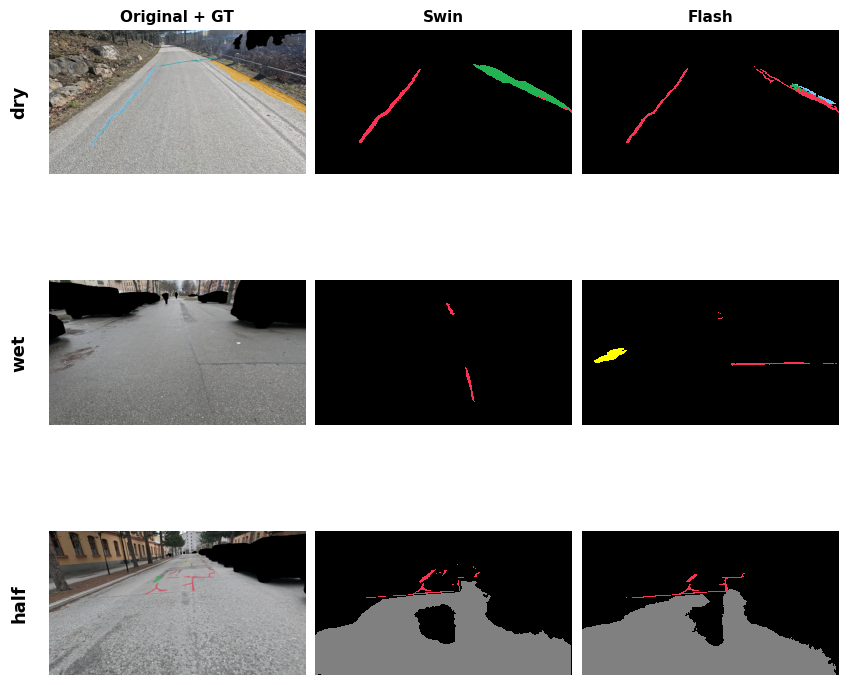

saved figures/weather_matched_scenes.png


In [13]:
ix = {c: image_ids(c) for c in CONDITIONS}
print('image ids per condition (to hand-pick a trio):')
for c in CONDITIONS: print(f'  {c}: {ix[c][:6]} ... ({len(ix[c])} total)')

# HAND-PICK here after eyeballing (recommended for the thesis figure), e.g.:
#   MANUAL_TRIO = {'dry': '<id>', 'wet': '<id>', 'half': '<id>'}
# Leave None to auto-select the visually most-similar trio (coarse 32x32 descriptor).
MANUAL_TRIO = None

def descriptor(img_id):
    rgb = _load_rgb(img_id)
    if rgb is None: return None
    g = cv2.resize(cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY), (32, 32)).astype(np.float32).ravel()
    return (g - g.mean()) / (g.std() + 1e-6)

if MANUAL_TRIO:
    trio = MANUAL_TRIO; print('using MANUAL_TRIO:', trio)
else:
    desc = {c: {i: descriptor(i) for i in ix[c]} for c in CONDITIONS}
    def dist(a, b): return float(np.mean((a - b) ** 2))
    best = None
    for di, da in desc['dry'].items():
        if da is None: continue
        wj = min(((j, dist(da, dv)) for j, dv in desc['wet'].items() if dv is not None), key=lambda x: x[1])
        hj = min(((j, dist(da, dv)) for j, dv in desc['half'].items() if dv is not None), key=lambda x: x[1])
        s = wj[1] + hj[1]
        if best is None or s < best[0]: best = (s, {'dry': di, 'wet': wj[0], 'half': hj[0]})
    trio = best[1]; print('approx-matched trio (by visual similarity):', trio)

cols = ['Original + GT'] + [m.capitalize() for m in MODELS]
fig, axes = plt.subplots(len(CONDITIONS), len(cols), figsize=(3.4 * len(cols), 3.2 * len(CONDITIONS)))
axes = np.atleast_2d(axes)
for r, c in enumerate(CONDITIONS):
    img_id = trio[c]; ov = overlay_gt(img_id)
    if ov is not None: axes[r, 0].imshow(ov)
    for j, m in enumerate(MODELS, start=1):
        _, pr = load_aligned(m, c, img_id)
        if pr is not None: axes[r, j].imshow(pr, cmap=CMAP, norm=NORM, interpolation='nearest')
    if r == 0:
        for j, name in enumerate(cols): axes[r, j].set_title(name, fontsize=11, fontweight='bold')
    axes[r, 0].text(-0.08, 0.5, c, transform=axes[r, 0].transAxes, rotation=90,
                    fontsize=13, fontweight='bold', va='center', ha='right')
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
plt.subplots_adjust(hspace=0.05, wspace=0.04)
Path('figures').mkdir(exist_ok=True); fig.savefig('figures/weather_matched_scenes.png', dpi=200, bbox_inches='tight')
plt.show(); print('saved figures/weather_matched_scenes.png')

## 10. Qualitative panels — first example per condition

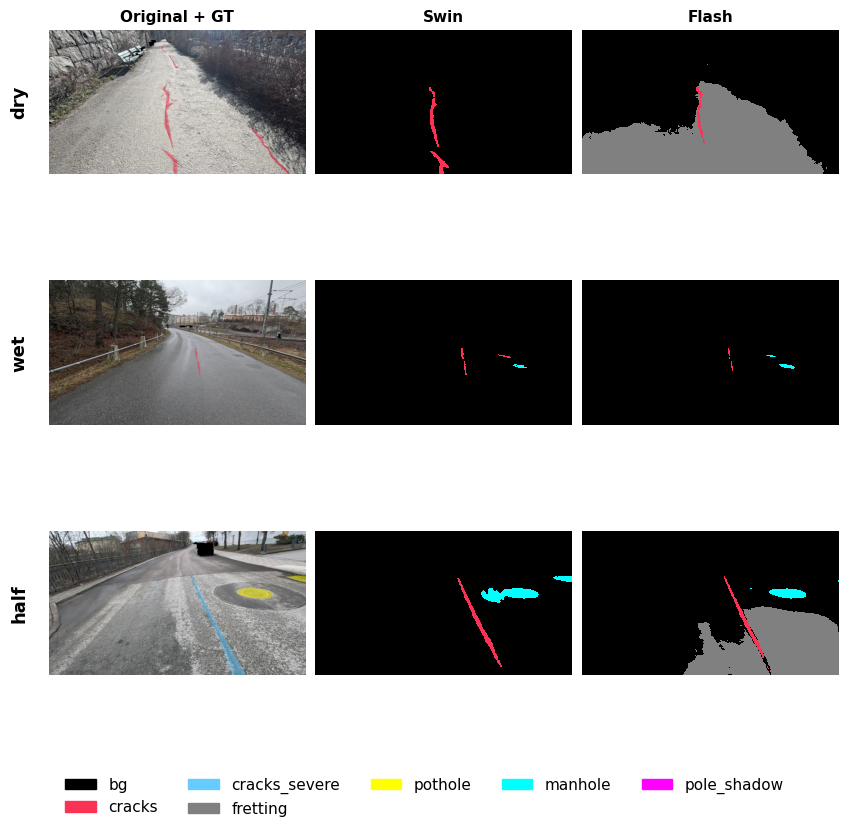

saved figures/weather_qualitative_panel.png


In [14]:
def first_common(cond):
    for i in image_ids(cond):
        if all(load_aligned(m, cond, i)[1] is not None for m in MODELS): return i
    return None
ex = [(c, first_common(c)) for c in CONDITIONS]; ex = [(c, i) for c, i in ex if i]
present = set()
for c, i in ex:
    g = cv2.imread(str(PATHS['gt'] / f'{i}.png'), cv2.IMREAD_GRAYSCALE)
    if g is not None: present |= set(np.unique(g))
    for m in MODELS:
        _, pr = load_aligned(m, c, i)
        if pr is not None: present |= set(np.unique(pr))
present = sorted(x for x in present if x < N)
legend = [mpatches.Patch(color=np.array(PALETTE[x]) / 255, label=CLASS_NAMES[x]) for x in present]
cols = ['Original + GT'] + [m.capitalize() for m in MODELS]
fig, axes = plt.subplots(len(ex), len(cols), figsize=(3.4 * len(cols), 3.2 * len(ex))); axes = np.atleast_2d(axes)
for r, (c, i) in enumerate(ex):
    ov = overlay_gt(i)
    if ov is not None: axes[r, 0].imshow(ov)
    for j, m in enumerate(MODELS, start=1):
        _, pr = load_aligned(m, c, i)
        if pr is not None: axes[r, j].imshow(pr, cmap=CMAP, norm=NORM, interpolation='nearest')
    if r == 0:
        for j, name in enumerate(cols): axes[r, j].set_title(name, fontsize=11, fontweight='bold')
    axes[r, 0].text(-0.08, 0.5, c, transform=axes[r, 0].transAxes, rotation=90,
                    fontsize=13, fontweight='bold', va='center', ha='right')
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
fig.legend(handles=legend, loc='lower center', ncol=min(len(legend), 5), frameon=False, fontsize=11)
plt.subplots_adjust(hspace=0.05, wspace=0.04)
Path('figures').mkdir(exist_ok=True); fig.savefig('figures/weather_qualitative_panel.png', dpi=200, bbox_inches='tight')
plt.show(); print('saved figures/weather_qualitative_panel.png')

## 11. Reading the results

From the tables above (computed live):

- **Real vs artifact (§1–2):** `mIoU_present` is also low → the collapse is **real**; `mIoU_no_bg`
  falls from ~40 (in-domain) to single digits.
- **Severity (§3):** conditions are different scenes, so the dry/half/wet ordering is confounded —
  the boxplot shows whether the degradation is roughly **uniform** across conditions or clearly worse when wetter.
- **Why (§4–5):** high `pred_%bg` + high `defect_miss` → the models **collapse toward background**
  and miss the (thin, low-contrast under rain/glare) defects; the confusion mass lands on `bg`.
- **Recoverable? (§7–8):** coarse grouping / boundary tolerance say whether it is *detection* failure
  (stays low) or *localization/subtype* imprecision (jumps up); the ensemble says whether Swin∨Flash helps.
- **Failure mode (§6):** miss-rate vs FP-rate — do the models stay silent (misses) or hallucinate (FPs)?

> Scope: only Swin-T and FlashInternImage have full weather runs. Add a model to `MODELS` after
> `make weather MODEL=<m> MODE=full`. No road appears in more than one condition (§9).